# Notebook 3: GPR foreground removal

In this notebook, we will alternatively use GPR for foreground removal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean
from gpr import *
from nautilus import Sampler, Prior
from scipy import optimize
from meer21cm.util import redshift_to_freq

In [2]:
import sys
import os
import importlib
#import functions # Replace with your actual file name
#importlib.reload(functions)
#from functions import *
from joblib import Parallel, delayed # this is for the multiprocessing but works with Jupyter notebooks
from tqdm import tqdm # this is to create a progress bar when running code 
import time

First, let us go back to the foreground and HI signal, and to see the structure of their covariances:

In [16]:
# Generate the mock and foreground signals
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='haslam',
    sp_indx_for_haslam_backend=-2.7,
)
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)


In [17]:
# extract their covariance 
cov_hi, _, _, _, = pca_clean(hi_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
cov_fg, _, _, _, = pca_clean(fg_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

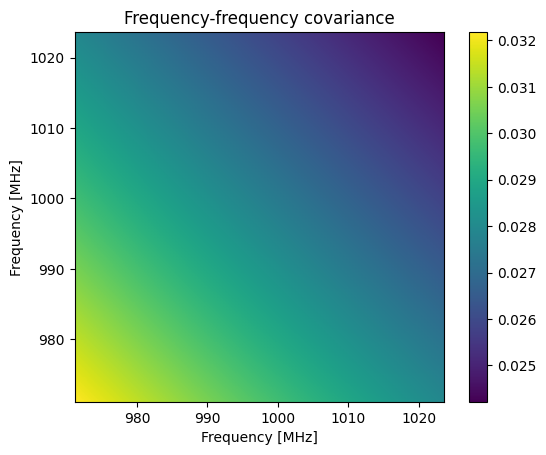

In [18]:
tot_map = hi_map + fg_map
cov_tot, _, eigen_values, _, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
plt.imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Frequency-frequency covariance')
#save_project_plot(plt.gcf(), week_number = 8, filename = "total_map_covariance.pdf")
plt.show()

NameError: name 'save_project_plot' is not defined

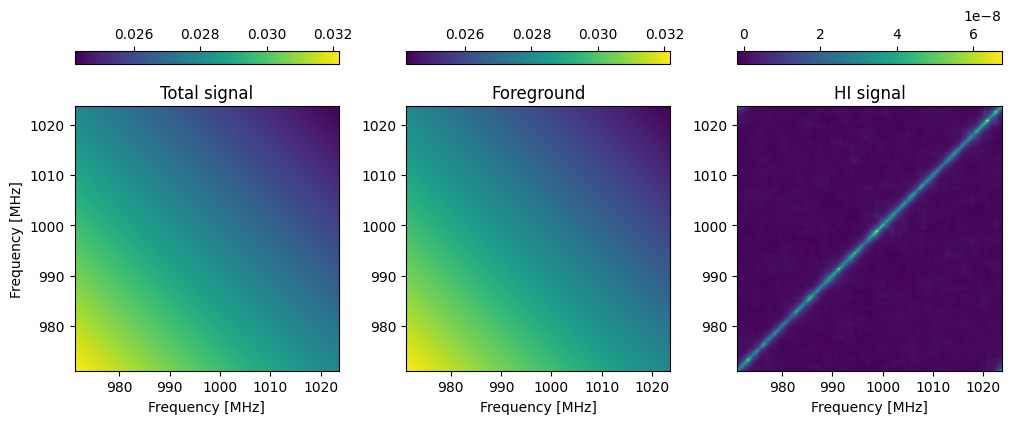

In [19]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,3,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('Total signal')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground')

im = axes[2].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[2].set_xlabel('Frequency [MHz]')
#axes[2].set_ylabel('Frequency [MHz]')
axes[2].set_title('HI signal')

save_project_plot(plt.gcf(), week_number = 6, filename = "tot_fg_hi_covariance_topcolourbar.pdf")
plt.show()


In [ ]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,3,figsize=(12,6), layout = "constrained")
im = axes[0].imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('Total signal')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground')

im = axes[2].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[2].set_xlabel('Frequency [MHz]')
#axes[2].set_ylabel('Frequency [MHz]')
axes[2].set_title('HI signal')

save_project_plot(plt.gcf(), week_number = 6, filename = "tot_fg_hi_covariance_rightcolourbar.pdf")
plt.show()


NameError: name 'save_project_plot' is not defined

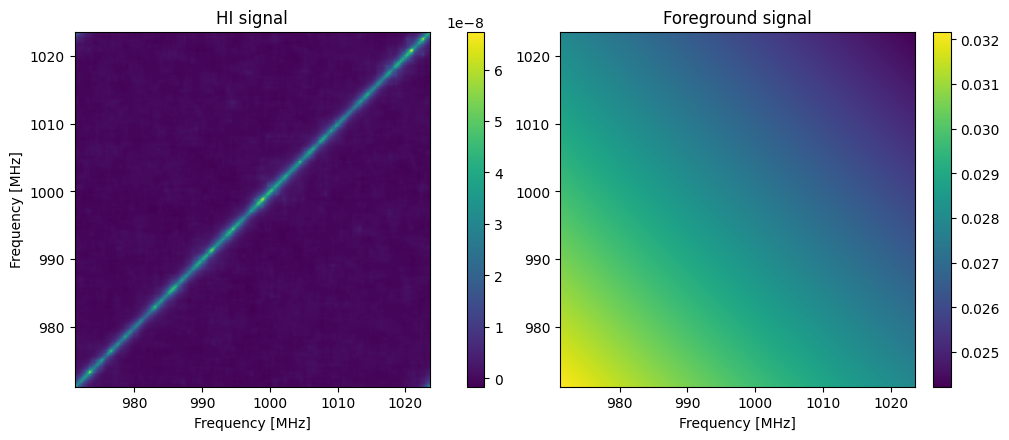

In [20]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('HI signal')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground signal')

save_project_plot(plt.gcf(), week_number = 8, filename = "HI_fg_covariance_comparison.pdf")
plt.show()

So we want two kernels that represent these two shown above. For example, let us check the exponential kernel first:

In [21]:
# create two exponential kernals
# one first l = 10, second with l = 100
exp_kern_1 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
exp_kern_2 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

NameError: name 'save_project_plot' is not defined

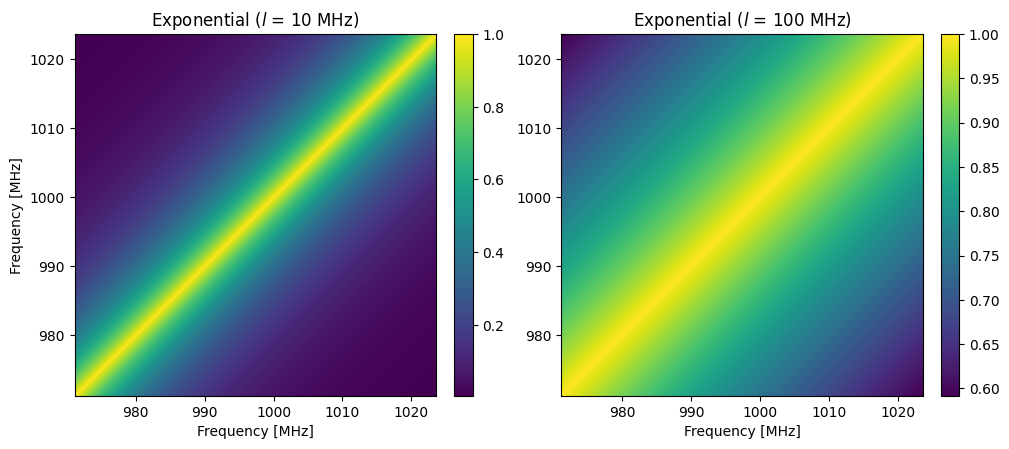

In [22]:
# plot the exponential kernals
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(exp_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential ($l$ = 10 MHz)')

im = axes[1].imshow(exp_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Exponential ($l$ = 100 MHz)')

save_project_plot(plt.gcf(), week_number = 8, filename = "exp_kernels_lengthscale_comparisons.pdf")
plt.show()


Ignore the amplitude for now, which I set to 1. I simply change $l$, which controls the width of the diagonal stripe as you can see. Larger the l (correlation length), wider the stripe. It is fairly obvious that for HI we need a very small length, say $l=1$ MHz: 

In [23]:
# test a rough estimate of the amplitude of the cov
sigma_hi_kern = np.sqrt(np.diagonal(cov_hi).mean())
l_hi = 1
exp_kern_hi = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_hi_kern,l_hi)


NameError: name 'save_project_plot' is not defined

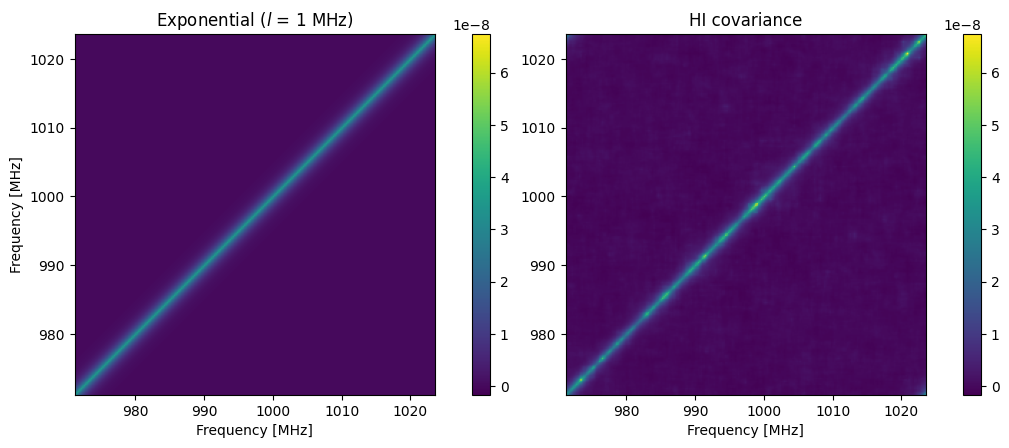

In [24]:
# plot the exponential kernal with l = 1 and the HI covariance
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
vmin = np.min([exp_kern_hi.min(), cov_hi.min()])
vmax = np.max([exp_kern_hi.max(), cov_hi.max()])
im = axes[0].imshow(
    exp_kern_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential ($l$ = 1 MHz)')

im = axes[1].imshow(
    cov_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'HI covariance')

save_project_plot(plt.gcf(), week_number = 8, filename = "exponential_HI_signal_covariance_comparison.pdf")
plt.show()


Now let us look at the foregrounds, which can be modelled by a RBF kernel:

In [25]:
# create two rbf kernals
# first with l = 10, second with l = 100
rbf_kern_1 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
rbf_kern_2 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

NameError: name 'save_project_plot' is not defined

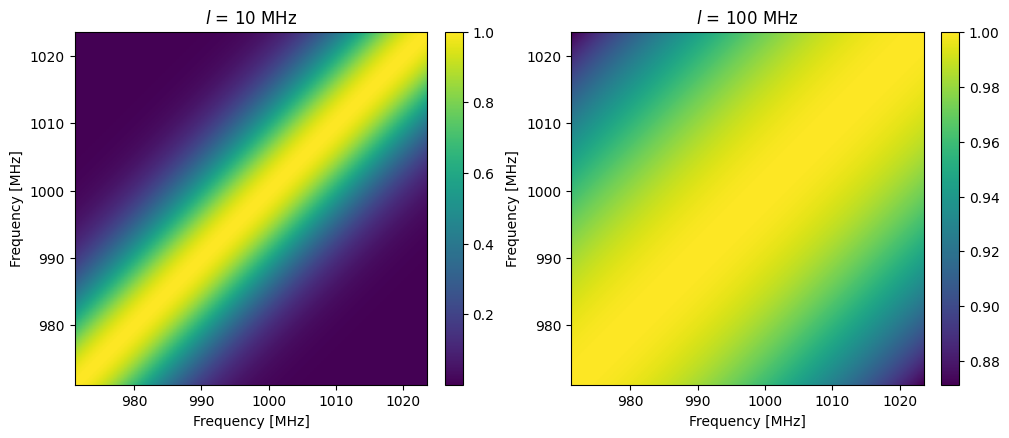

In [26]:
# plot the rbf kernals
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(rbf_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 10 MHz')

im = axes[1].imshow(rbf_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'$l$ = 100 MHz')

save_project_plot(plt.gcf(), week_number = 8, filename = "rbf_kernels_lengthscale_comparisons.pdf")
plt.show()

You can see the for a RBF kernel, the kernel is much wider than the exp kernel for the same correlation length. This is ideal to describe the smooth foregrounds.

NameError: name 'save_project_plot' is not defined

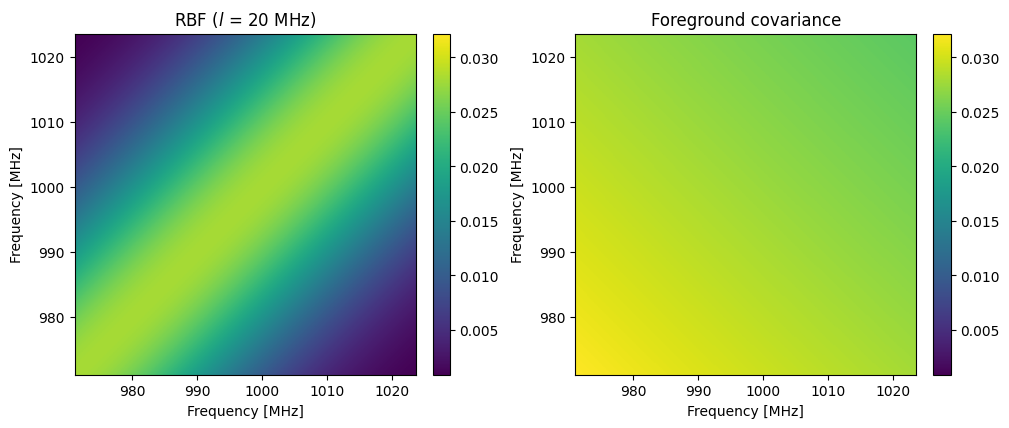

In [27]:
# plot the rbf kernal and the foreground covariance for comparison
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.0
l_fg = 20
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'RBF $(l$ = 20 MHz)')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')

save_project_plot(plt.gcf(), week_number = 8, filename = "rbf_fg_covariance_comparisons.pdf")
plt.show()

However, this is still not quite matching. The problem is, the foreground has something called spectral index. That is to say, the brightness of the foreground scales according to frequency:

$$
T(f) = T_0(f_0) * (f/f_0)^\gamma
$$

This is where we want to improve from the previous work. In the RBF kernel, I allow an additional input $\gamma$:

NameError: name 'save_project_plot' is not defined

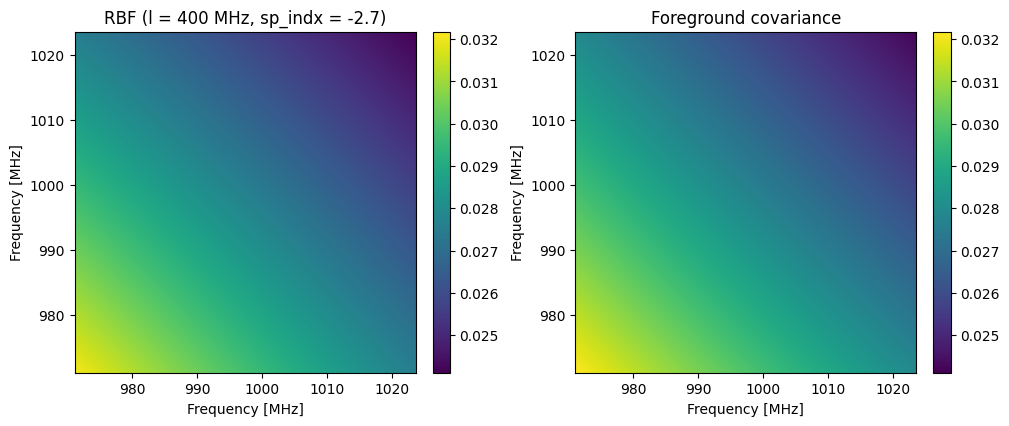

In [28]:
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.07
l_fg = 400
sp_indx_fg = -2.7
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg,sp_indx_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(f'RBF (l = {l_fg} MHz, sp_indx = {sp_indx_fg})')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')

save_project_plot(plt.gcf(), week_number = 8, filename = "rbf2_fg_covariance_comparisons.pdf")
plt.show()

As you can see, it starts to resemble the foreground covariance.

Furthermore, we need to add in the thermal noise. There are more physical ways of generating the noise, but for now let us just add in a Gaussian noise with a standard deviation that I take from 2407.21626

In [29]:
# generate gaussian note and extract its covariance
sigma_noise = 1.21 * 1e-3
noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

As we have discussed, the noise covariance should be purely diagonal:

NameError: name 'save_project_plot' is not defined

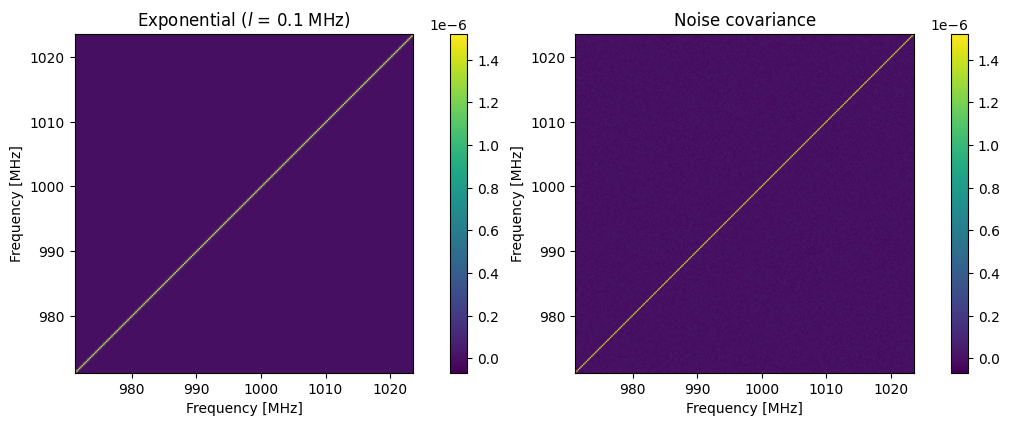

In [30]:
# plot the exponent kernal with l = 0.1 and the noise covariance
exp_kern_noise = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_noise,0.1)
fig,axes = plt.subplots(1,2,figsize=(10,5), layout = "constrained")
vmin = np.min([exp_kern_noise.min(), cov_noise.min()])
vmax = np.max([exp_kern_noise.max(), cov_noise.max()])
im = axes[0].imshow(
    exp_kern_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential ($l$ = 0.1 MHz)')

im = axes[1].imshow(
    cov_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='right', fraction = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')


save_project_plot(plt.gcf(), week_number = 8, filename = "exp_noise_covariance_comparisons.pdf")
plt.show()

Note that this is just for illustration. To find the true kernel, we need to perform the optimisation routine to find the kernel parameters. See Eq 18.

In [31]:
tot_map = hi_map + fg_map + noise_map

In [32]:
cov_tot,_,_,_ = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

Now, let us try to find the best fit parameter for the GPR:

In [33]:
best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:33: RuntimeWarning: overflow encountered in exp
  return np.nan_to_num(sigma**2 * np.exp(-np.abs(x-y)/l))
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/var/folders/1y/bkp6bf212cl3sq0d7bgcgtvm0000gn/T/ipykernel_62703/4092381761.py:1: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))


In [34]:
fitted_pars = best_fit
fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])
fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])

Text(0.5, 1.0, 'Noise covariance')

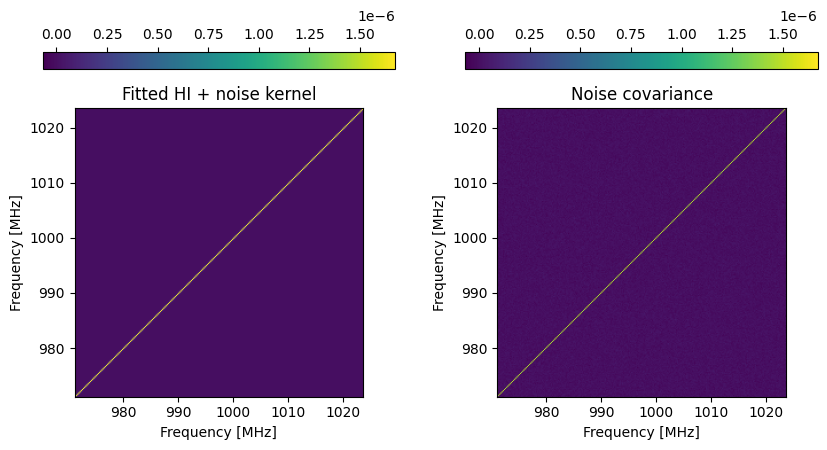

In [35]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_hi_kern.min(), cov_noise.min()])
vmax = np.max([fitted_hi_kern.max(), cov_noise.max()])
im = axes[0].imshow(fitted_hi_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Fitted HI + noise kernel')

im = axes[1].imshow(cov_noise,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')



Text(0.5, 1.0, 'Foreground covariance')

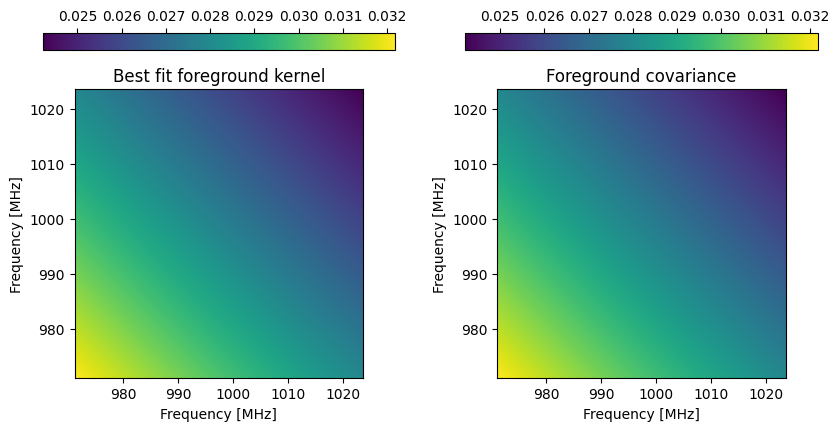

In [36]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_fg_kern.min(), cov_fg.min()])
vmax = np.max([fitted_fg_kern.max(), cov_fg.max()])
im = axes[0].imshow(fitted_fg_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Best fit foreground kernel')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Foreground covariance')



Now, with the fitted foreground kernel, we can remove the foreground from the data:

In [37]:
fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
)
res_map = tot_map - fg_remov

In [38]:
noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
)

Now let us see the removed map versus the actual map:

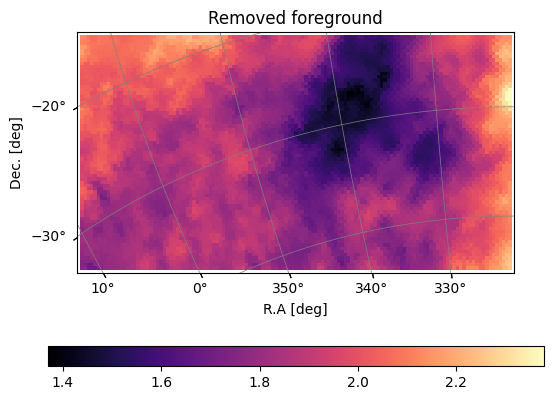

In [39]:
plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

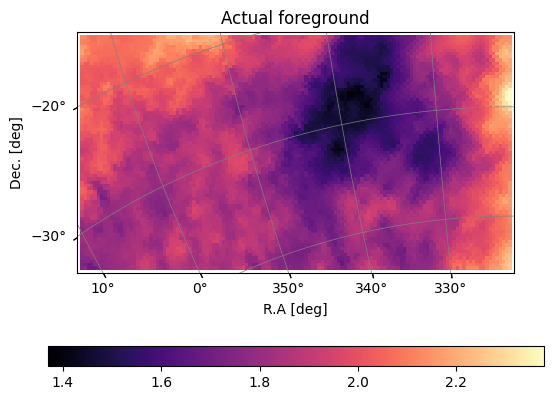

In [40]:
plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

As you can see the removal is quite good.

Let us check the power spectrum:

In [41]:
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins = np.linspace(0, 1.2, 21)

In [42]:
mock.data = hi_map
mock.grid_data_to_field();
power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = res_map
mock.grid_data_to_field();
power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = noise_residual
mock.grid_data_to_field();
power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
power_cy_res -= power_cy_noise
power_1d_res -= power_1d_noise
# Here we add in the noise, so we need to subtract out the noise power
# in real data analysis noise power can be calculated from the noise sigma

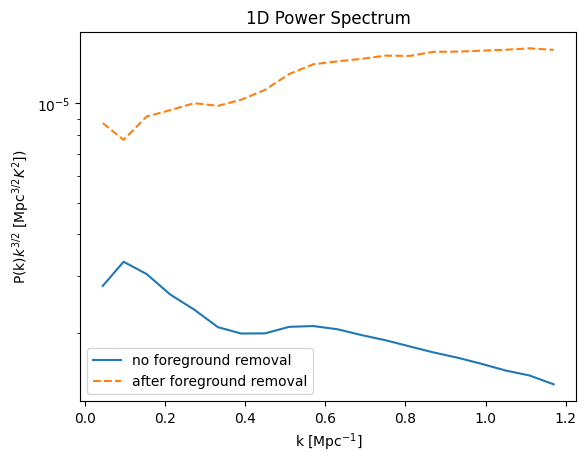

In [43]:
plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal')
plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
plt.yscale('log')
plt.title('1D Power Spectrum')
plt.legend()



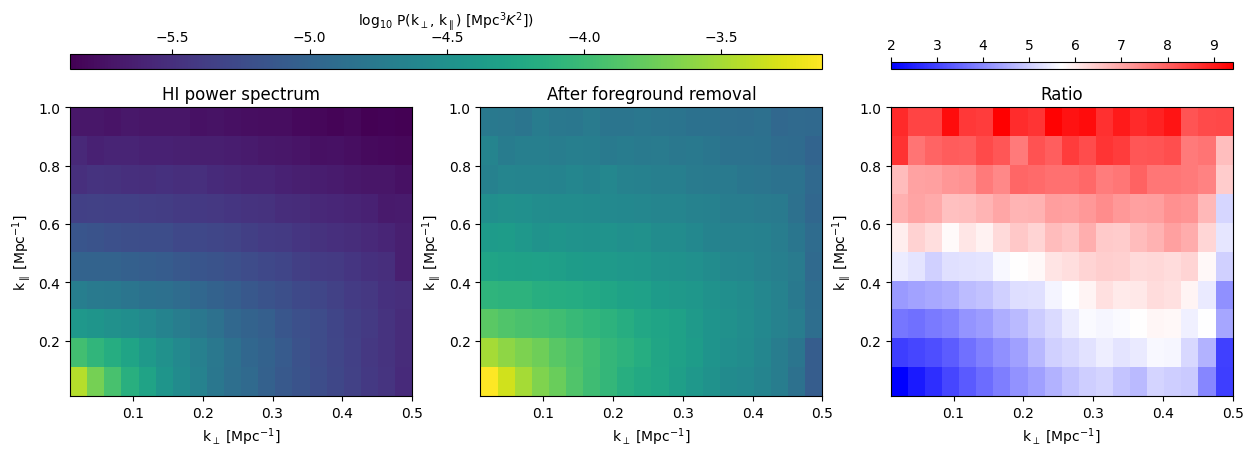

In [44]:
vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('HI power spectrum')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('After foreground removal')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
plt.show()

Things for you to try:
1. Play with the kernels and understand the kernel functions
2. Can you find a better optimisation routine to achieve a better result?

# My code

## Define functions

In [45]:
def plot_HI_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None):

    # generate gaussian noise and extract its covariance
    sigma_noise = 1.21 * 1e-3
    noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
    cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

    # create hi signal kernal using exponential kernal and best fit parameters
    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout = "constrained")
    
    im = axes[0].imshow(fitted_hi_kern, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Fitted HI + noise kernel')
    
    im = axes[1].imshow(cov_noise, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Noise covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"hi_signal_kernal_comparison_{method}.pdf")
    
    #plt.tight_layout()
    plt.show()

In [72]:
def plot_foreground_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True,
                                            kernel = None, eta = 0.0, l_fg = 0.0, l_fg_fixed = None):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if l_fg_fixed == True and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg)

    if l_fg_fixed == True and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg, fitted_pars[4])
    
    # plot the best fitted kernal and foreground covariance with independent colour scales
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout = "constrained")
    im = axes[0].imshow(fitted_fg_kern, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Best fit foreground kernel')
    
    im = axes[1].imshow(cov_fg, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='right', fraction = 0.05)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Foreground covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"fg_signal_kernal_comparison_{method}.pdf")
    
    #plt.tight_layout()
    plt.show()

In [74]:
def foreground_kernal_removal_plots(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True,
                                   kernel = None, eta = 0.0, l_fg = 0.0, l_fg_fixed = None):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if l_fg_fixed == True and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg)

    if l_fg_fixed == True and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg, fitted_pars[4])     
        
    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_kernal_foreground_{method}.pdf")

    plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_actual_foreground_{method}.pdf")

In [75]:
def kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method, save_plot = False, week_number = None, sp_indx_fg = True, 
                                                                power_spectrum = True, log_power_spectrum = True, cylindrical_power_spectrum = True,
                                                               kernel = None, eta = 0.0, l_fg = 0.0, l_fg_fixed = None):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    if kernel == rbf_kernel and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])
    
    if kernel == rbf_kernel and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3])

    if kernel == matern_kernel and eta == 5/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel and eta == 3/2:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if kernel == matern_kernel:
        fitted_fg_kern = matern_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], eta)

    if l_fg_fixed == True and sp_indx_fg == False:
        fitted_fg_kern = rbf_kernel_no_sp_indx(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg)

    if l_fg_fixed == True and sp_indx_fg == True:
        fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , l_fg, fitted_pars[4])     

    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins = np.linspace(0, 1.2, 21)

    mock.data = hi_map
    mock.grid_data_to_field();
    power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = res_map
    mock.grid_data_to_field();
    power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = noise_residual
    mock.grid_data_to_field();
    power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    power_cy_res -= power_cy_noise
    power_1d_res -= power_1d_noise
    # Here we add in the noise, so we need to subtract out the noise power
    # in real data analysis noise power can be calculated from the noise sigma

    if power_spectrum == True:
        # 1D power spectrum
        plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal', color = 'blue')
        plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--', color = 'red')
        plt.xlabel('k [Mpc$^{-1}$]')
        plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
        plt.title('1D Power Spectrum')
        plt.legend()
        if save_plot:
            save_project_plot(plt.gcf(), week_number=week_number,
                              filename=f"1d_power_spectrum_{method}.pdf")
        plt.show()

    if log_power_spectrum == True:
        # log 1D power spectrum
        log_power_1d_hi = np.log10(power_1d_hi)
        log_power_1d_res = np.log10(power_1d_res)
        plt.plot(k_1d, log_power_1d_hi, label='no foreground removal', color = 'blue', linewidth = 1)
        plt.plot(k_1d, log_power_1d_res, label='after foreground removal',ls='--', color = 'red', linewidth = 1)
        plt.xlabel('k [Mpc$^{-1}$]')
        plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)')
        plt.title('1D Power Spectrum')
        plt.legend()
        # save plot
        if save_plot == True:
            save_project_plot(plt.gcf(), week_number = week_number, 
                              filename = f"log_1d_power_spectrum_{method}.pdf") 
        plt.show()

    if cylindrical_power_spectrum == True:
        # cylindrical power spectrum
        vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
        vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
        fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
        axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
        axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[0].set_title('HI power spectrum')
        im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
        axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[1].set_title('After foreground removal')
        cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
        cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
        im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
        axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
        axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
        axes[2].set_title('Ratio')
        cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
        # save plot
        if save_plot == True:
            save_project_plot(plt.gcf(), week_number = week_number, 
                              filename = f"cylindrical_power_spectrum_{method}.pdf")
        plt.show()

In [49]:
# copy and paste in function which makes saving files easier
def save_project_plot(fig, week_number, filename):
    """
    Saves a matplotlib figure to a specific week's folder.
    Example: week_number=1 saves to .../outputs/week1/
    """
    # 1. Define the base path
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    
    # 2. Create the week-specific folder name
    week_folder = f"week{week_number}"
    
    # 3. Combine them into a full path
    target_dir = os.path.join(base_path, week_folder)
    
    # 4. Create the directory if it doesn't exist yet
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created new directory: {target_dir}")
    
    # 5. Define the final file path
    save_path = os.path.join(target_dir, filename)
    
    # 6. Save the figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {save_path}")

In [50]:
# generate a list of 100 integers [1, 2, 3, ..., 100]
seeds = np.arange(1, 101)

## Without any optimisations and just initial guesses

In [115]:
fitted_pars = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]


In [128]:
fitted_pars = np.array([1.9e-4, 1.8e-1, 1, 400, -2.7], dtype = float)
fitted_pars = [1.29331312e-03, 1.77499636e-01, 8.16983100e-02, 490, -2.72257223e+00]
print(fitted_pars)

[0.00129331312, 0.177499636, 0.08169831, 490, -2.72257223]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/hi_signal_kernal_comparison_inital_guesses.pdf


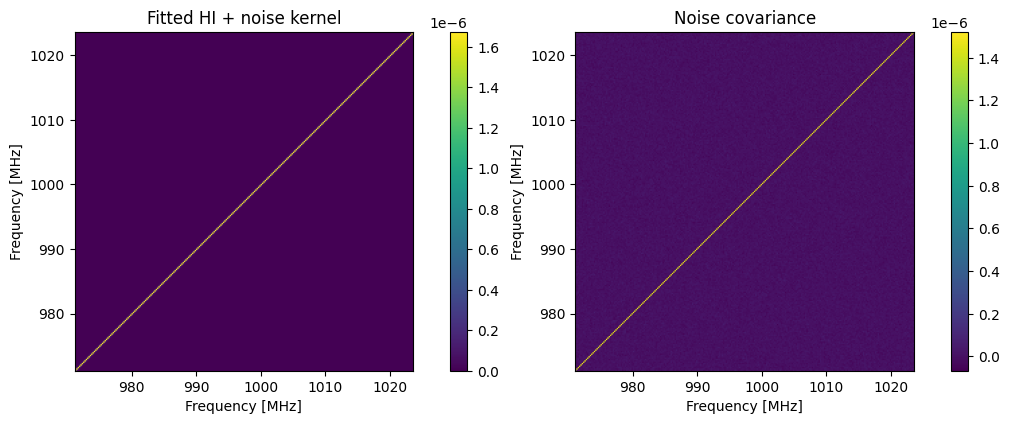

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/fg_signal_kernal_comparison_inital_guesses.pdf


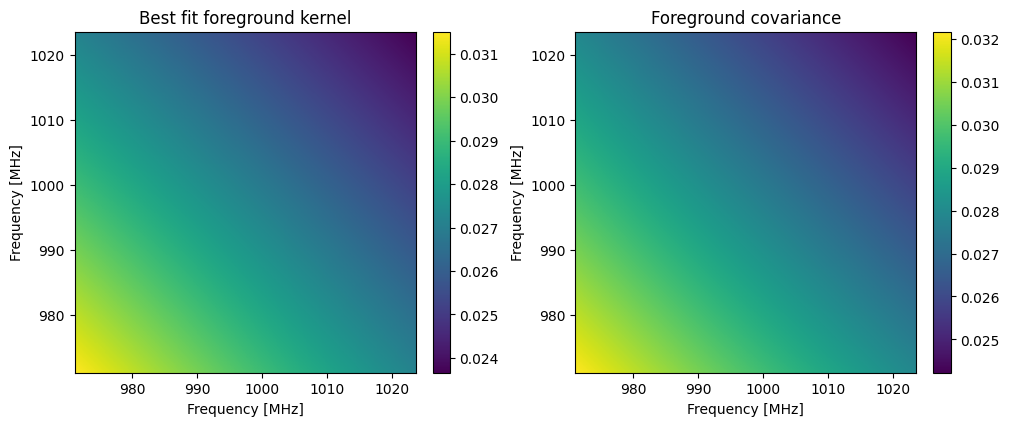

In [129]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "inital_guesses", save_plot = True, week_number = 8)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "inital_guesses", save_plot = True, week_number = 8, kernel = rbf_kernel)
#foreground_kernal_removal_plots(fitted_pars, method = "inital_guesses", save_plot = True, week_number = 8)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/1d_power_spectrum_inital_guesses.pdf


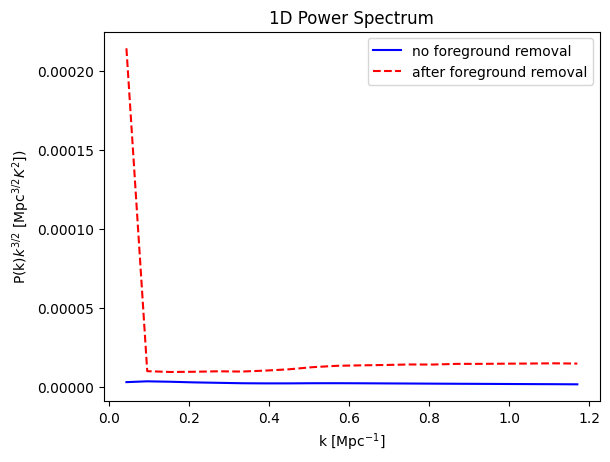

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/log_1d_power_spectrum_inital_guesses.pdf


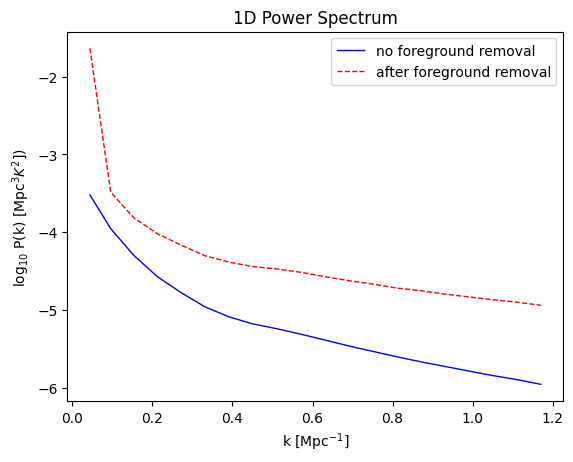

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/cylindrical_power_spectrum_inital_guesses.pdf


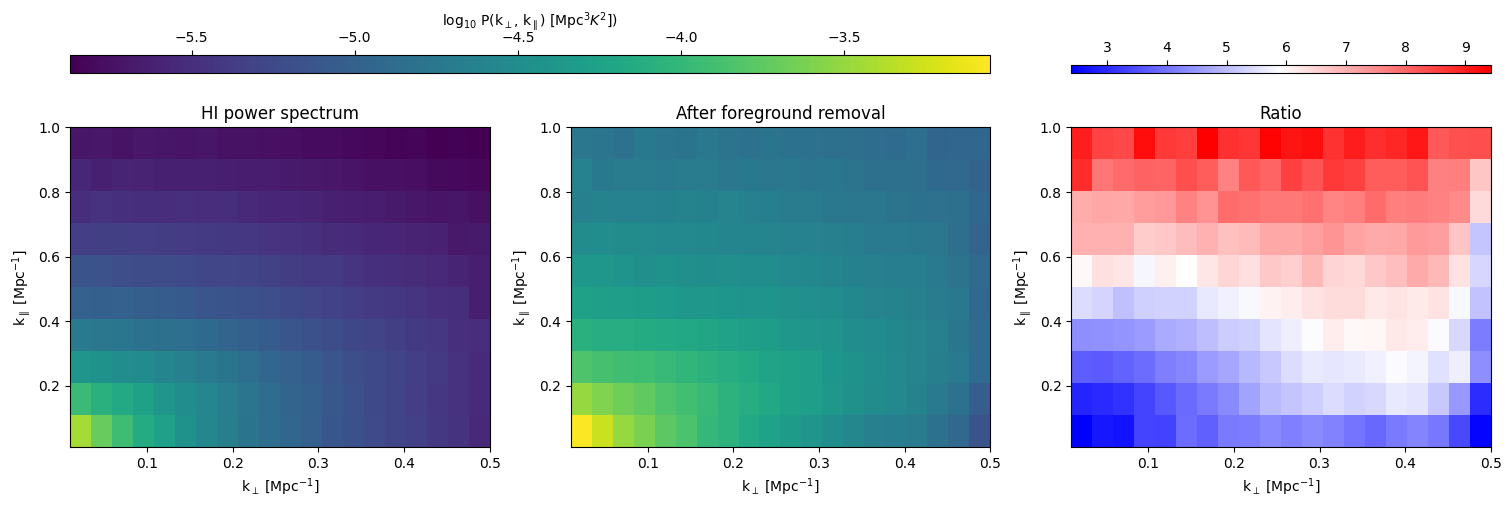

In [130]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "inital_guesses", save_plot = True, week_number = 8,
                                                           kernel = rbf_kernel)

## Scipy optimise minimise with no bounds

In [120]:
### best fit parameters extracted
#### 0 = sigma_hi = amplitude of the HI signal
#### 1 = sigma_fg = amplitude of the foregrounds
#### 2 = l_hi = correlation length of the HI signal
#### 3 = l_fg = correlation length of the foreground
#### 4 = sp_indx = spectral index scaling

In [121]:
# lets try a different scipy optimise function = minimize
tot_map = hi_map + fg_map + noise_map
cov_tot,_,_,_ = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args) #  method = 'Nelder-Mead'

In [122]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: False
Reason for stopping: Desired error not necessarily achieved due to precision loss.
Optimized Parameters: [ 6.46189880e-01  9.95758250e-02  3.37992597e+03  4.00367278e+02
 -3.69321618e+01]
Log-Marginial Likeligood: -1231.4628349035102


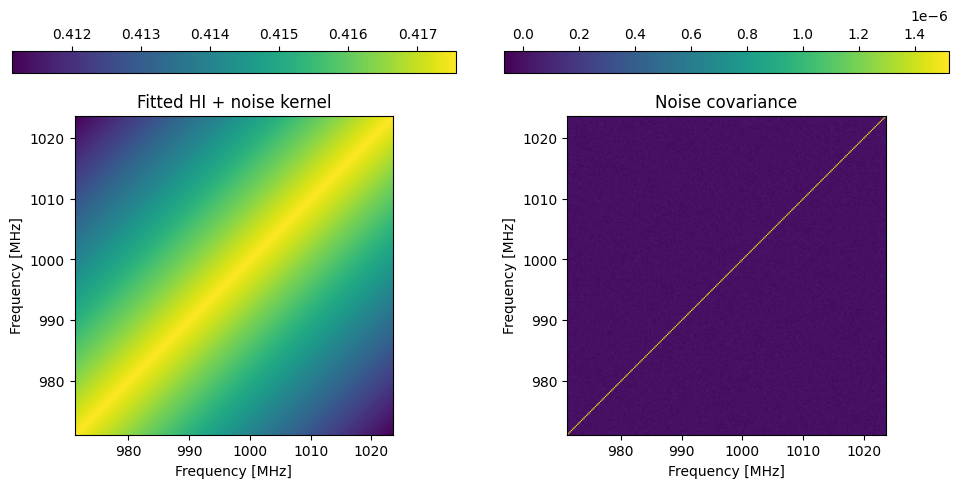

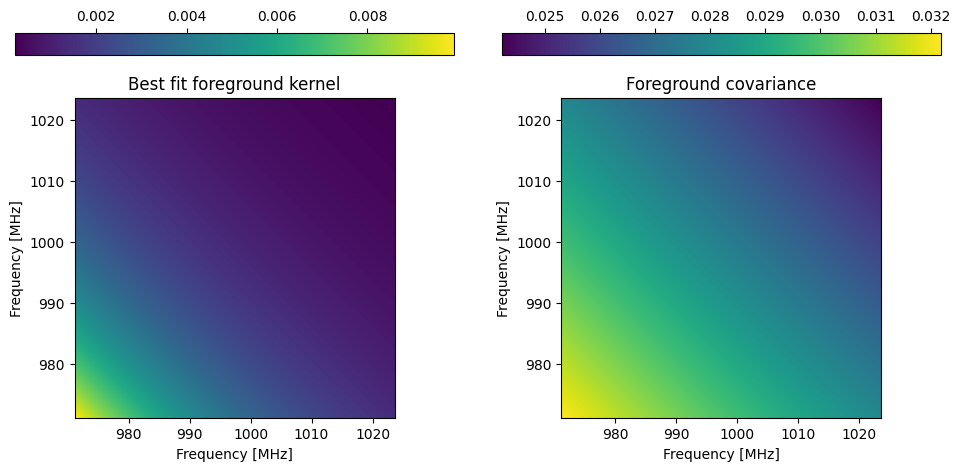

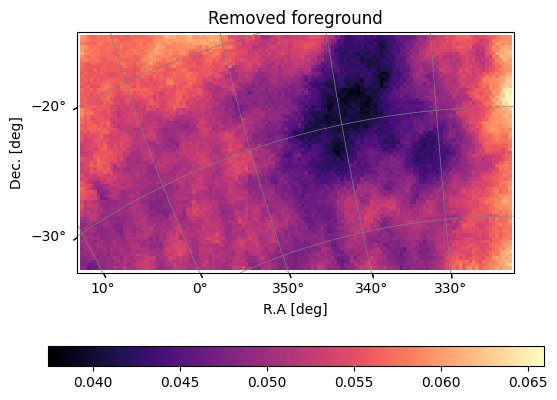

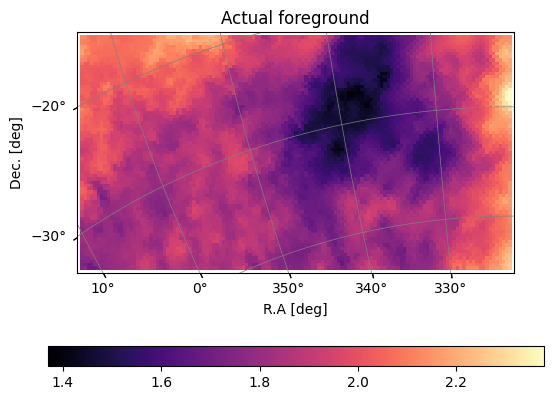

In [123]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_no_bounds", save_plot = False, week_number = 8)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_no_bounds", save_plot = False, week_number = 8)
foreground_kernal_removal_plots(fitted_pars, method = "default_no_bounds", save_plot = False, week_number = 8)

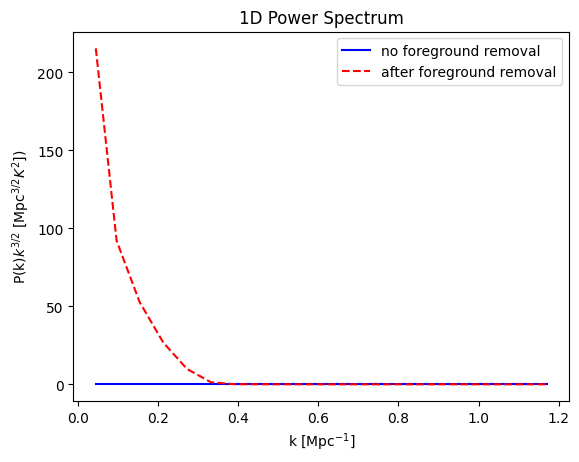

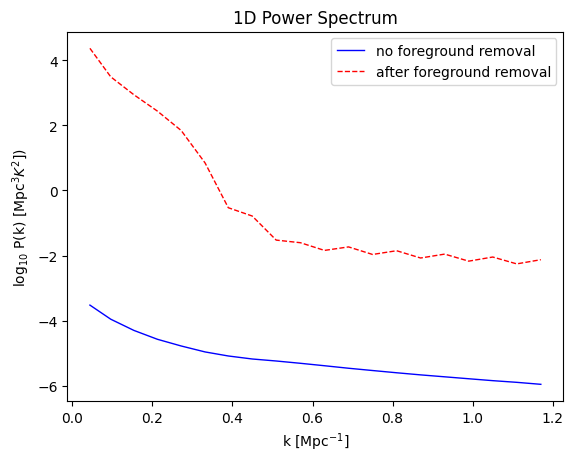

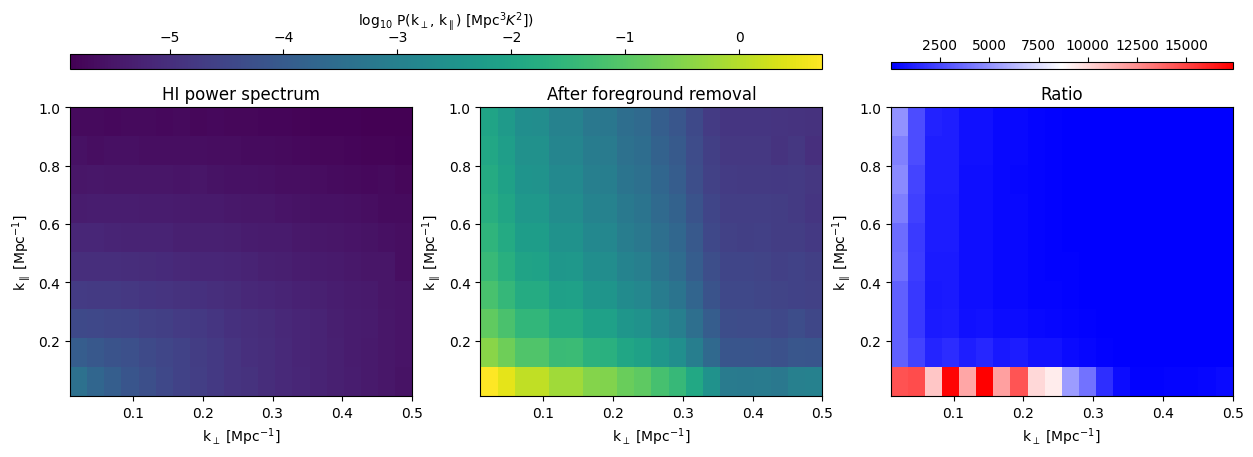

In [124]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_no_bounds", save_plot = False, week_number = 8)

## Scipy optimise minimise with bounds

In [125]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, None),   # Amplitudes must be positive
    (1e-6, None), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 100.0),  # foreground length scale (MHz)
    (None, None)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #  method = 'Nelder-Mead'

In [126]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29113053e-03  1.19845003e-01  8.04188892e-02  1.00000000e+02
 -2.70299273e+00]
Log-Marginial Likeligood: -1535.211784600934


In [137]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 8)

In [136]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = False, week_number = 8)

In [129]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, 0.5),     # sigma_hi
    (1e-6, 0.5),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 1000.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #  method = 'Nelder-Mead'

In [130]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29253944e-03  1.29844942e-01  8.12243091e-02  3.99999585e+02
 -2.90625526e+00]


In [131]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29253944e-03  1.29844942e-01  8.12243091e-02  3.99999585e+02
 -2.90625526e+00]
Log-Marginial Likeligood: -1539.1832252768527


In [134]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [135]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## L-BFGS-B

In [138]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, None),     # sigma_hi
    (1e-6, None),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 10000.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #  method = 'Nelder-Mead'

In [139]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29126672e-03  1.30754391e-01  1.00000000e-04  4.00000220e+02
 -2.70097048e+00]


In [140]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29126672e-03  1.30754391e-01  1.00000000e-04  4.00000220e+02
 -2.70097048e+00]
Log-Marginial Likeligood: -1538.4584476250636


In [141]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [142]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## SLSQP

In [143]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, None),     # sigma_hi
    (1e-6, None),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 10000.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'L-BFGS-B')

In [144]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29126672e-03  1.30754391e-01  1.00000000e-04  4.00000220e+02
 -2.70097048e+00]


In [145]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29126672e-03  1.30754391e-01  1.00000000e-04  4.00000220e+02
 -2.70097048e+00]
Log-Marginial Likeligood: -1538.4584476250636


In [146]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [147]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## TNC

In [148]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, None),     # sigma_hi
    (1e-6, None),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 10000.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'TNC')

In [149]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29261644e-03  1.29268888e-01  8.12538096e-02  5.04623909e+02
 -2.71291495e+00]


In [150]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: False
Reason for stopping: Max. number of function evaluations reached
Optimized Parameters: [ 1.29261644e-03  1.29268888e-01  8.12538096e-02  5.04623909e+02
 -2.71291495e+00]
Log-Marginial Likeligood: -1539.5961942965182


In [151]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [152]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## Powell

In [153]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, None),     # sigma_hi
    (1e-6, None),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 500.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Powell')

In [154]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29470198e-03  1.30110715e-01  8.00525327e-02  4.99999995e+02
 -2.84678279e+00]


In [155]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29470198e-03  1.30110715e-01  8.00525327e-02  4.99999995e+02
 -2.84678279e+00]
Log-Marginial Likeligood: -1539.5852989503185


In [156]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [157]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## Global optimisers

## Differential Evolution (LML = -1540 = lowest)

In [158]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, 0.5),     # sigma_hi (exp)
    (1e-6, 0.5),        # sigma_fg (rbf)
    (1e-1, 5.0),       # l_hi (exp)
    (10.0, 1000.0),   # l_fg (rbf)
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.differential_evolution(func = function_to_optimise, x0 = x0, args = args, bounds = bounds,
                                          tol = 1e-6, seed = 42, maxiter = 1000, workers = 1)

In [159]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.30129880e-03  1.27374952e-01  1.00000000e-01  9.99916376e+02
 -2.72753491e+00]


In [160]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.30129880e-03  1.27374952e-01  1.00000000e-01  9.99916376e+02
 -2.72753491e+00]
Log-Marginial Likeligood: -1540.1806904186694


In [165]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 5)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 5)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 5)

In [166]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 5)

## Basin-hopping, local and random jumps

In [ ]:
minimizer_kwargs = {"method": "L-BFGS-B", "args": args, "bounds": bounds}
best_fit = optimize.basinhopping(func = function_to_optimise, x0 = x0, 
                                 minimizer_kwargs = minimizer_kwargs, niter = 200, seed = 42)

In [ ]:
print(x0)
print(best_fit.x)

In [ ]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

In [ ]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [ ]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## Dual annealing, simulated annealing and local search

In [ ]:
bounds = [
    (1e-6, 0.5),     # sigma_hi (exp)
    (1e-6, 0.5),        # sigma_fg (rbf)
    (1e-6, 5.0),       # l_hi: keep physically reasonable, not vanishingly small (exp)
    (10.0, 10000.0),  # l_fg (rbf)
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.dual_annealing(func = function_to_optimise, bounds = bounds, args = args,
                                   seed = 42, maxiter = 1000)

In [ ]:
print(x0)
print(best_fit.x)

In [ ]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

In [ ]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

In [ ]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = False, week_number = 8)

## Nelder-Mead method (LML = -1540 = lowest)

In [173]:
# lets try optimize.fmin again
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_noise, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [174]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x
#print(best_fit)

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29331312e-03  1.27499636e-01  8.16983100e-02  1.00000000e+03
 -2.72257223e+00]
Log-Marginial Likeligood: -1540.4450964433133


In [179]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)

In [180]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)

In [197]:
# lets try optimize.fmin again
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_noise, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

print(l_fg)

400


In [ ]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x
#print(best_fit)

In [ ]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)
#foreground_kernal_removal_plots(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)

In [ ]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 8)

# Using Bayesian Optimisation with GPyOPT (not good)

### Here, Baysian Optimisation will quickly find the global minimum of a multi-dimensional function 
### It incorporates information learned in the previous function evaluations to choose an optimal set of coordinates for the next evaluation. It does this by calculating the posterior predictive distribution for the function's value at each point.

In [234]:
import GPyOpt

In [235]:
# define the domain (bounds)
# GPyOpt uses a list of dictionaries to define the search space
domain = [
    {'name': 'sigma_noise',   'type': 'continuous', 'domain': (1e-6, 0.5)},
    {'name': 'sigma_fg_kern', 'type': 'continuous', 'domain': (1e-6, 0.5)},
    {'name': 'l_hi',          'type': 'continuous', 'domain': (1e-6, 5.0)},
    {'name': 'l_fg',          'type': 'continuous', 'domain': (10.0, 10000.0)},
    {'name': 'sp_indx_fg',    'type': 'continuous', 'domain': (-5.0, -0.1)}
]

In [236]:
# wrap the function
# GPyOpt passes X as a (N, D) array so we need to extract the row
def gpyopt_wrapper(x):
    # x is a 2D array [[val1, val2, ...]]
    return function_to_optimise(x[0], *args)


In [237]:
# initialise the optimiser
myBopt = GPyOpt.methods.BayesianOptimization(
    f = gpyopt_wrapper,            # Function to minimize
    domain = domain,               # Box constraints
)

In [238]:
# run the optimization
myBopt.run_optimization(max_iter=50)

In [239]:
print(myBopt.model.model)


Name : GP regression
Objective : 76.3232141506725
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                   value  |    constraints    |  priors
  Mat52.variance           |       1.134494256491904  |        +ve        |        
  Mat52.lengthscale        |      1.1203253259599797  |        +ve        |        
  Gaussian_noise.variance  |  2.1562752796415462e-08  |  1e-09,1000000.0  |        


In [240]:
# get results
fitted_pars = myBopt.x_opt
print(x0)
print(fitted_pars)

[ 1.2100000e-03  1.8255182e-01  1.0000000e+00  4.0000000e+02
 -2.7000000e+00]
[ 1.82003418e-02  4.07122063e-01  4.50422131e+00  6.51158638e+03
 -5.00000000e+00]


In [97]:
#plot_HI_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)
#plot_foreground_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)
#foreground_kernal_removal_plots(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)

In [96]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)

In [243]:
def gpyopt_wrapper(x):
    # Convert log-space back to linear for your physics function
    params = np.copy(x[0])
    params[0] = 10**params[0] # sigma_noise
    params[1] = 10**params[1] # sigma_fg_kern
    params[3] = 10**params[3] # l_fg
    return function_to_optimise(params, *args)

In [244]:
myBopt = GPyOpt.methods.BayesianOptimization(
    f=gpyopt_wrapper,
    domain=domain,
    model_type='GP',
    acquisition_type='EI',
    normalize_Y=True,
    initial_design_numdata=20,
    # --- RESTARTS CONFIG ---
    num_restarts=10,             # Restarts for the GP model hyperparameters
    acquisition_optimizer_type='lbfgs', 
    max_iters=1000               # Internal iterations for GP fitting
)

In [ ]:
myBopt.run_optimization(max_iter=50)

In [ ]:
res = myBopt.x_opt.copy()
res[0], res[1], res[3] = 10**res[0], 10**res[1], 10**res[3]

In [ ]:
res = myBopt.x_opt.copy()
print(x0)
print("Best Physical Parameters:", res)

In [ ]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)
#foreground_kernal_removal_plots(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)

In [ ]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "nelder_mead", save_plot = False, week_number = 5)

# MCMC

In [186]:
import emcee
import numpy as np
import corner
import matplotlib.pyplot as plt
import time

In [181]:
def log_prior(theta):
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = theta
    if (1e-6  < sigma_hi   < 0.005  and
        1e-6  < sigma_fg   < 0.5    and
        0.01  < l_hi       < 0.5    and
        100.0 < l_fg       < 5000.0 and
        -5.0  < sp_indx_fg < -0.1):
        return 0.0
    return -np.inf

In [182]:
def log_likelihood(theta, xarr, cov_tot):
    sigma_hi, sigma_fg, l_hi, l_fg, sp_indx_fg = theta
    k_hi  = exponential_kernel(xarr, xarr, sigma_hi, l_hi)
    k_fg  = rbf_kernel(xarr, xarr, sigma_fg, l_fg, sp_indx_fg)
    k_tot = k_hi + k_fg
    return log_marginal_likelihood(cov_tot, k_tot)

In [183]:
def log_probability(theta, xarr, cov_tot):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, xarr, cov_tot)
    return lp + ll if np.isfinite(ll) else -np.inf

In [184]:
xarr     = mock.nu / 1e6
initial  = best_fit.x   # from differential evolution
nwalkers = 40
ndim     = len(initial)
nsteps   = 5000
discard  = 500

pos = initial + 1e-3 * np.random.randn(nwalkers, ndim) * initial

# Ensure all walkers satisfy priors
for i in range(nwalkers):
    while not np.isfinite(log_prior(pos[i])):
        pos[i] = initial + 1e-3 * np.random.randn(ndim) * initial

print("All walkers initialised within prior bounds")

All walkers initialised within prior bounds


In [187]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability,
    args=(xarr, cov_tot)
)

print("Burning in …")
start = time.time()
for i, result in enumerate(sampler.sample(pos, iterations=discard)):
    if (i + 1) % 50 == 0:
        elapsed   = time.time() - start
        remaining = elapsed / (i + 1) * (discard - i - 1)
        print(f"  Burn-in {i+1}/{discard} | elapsed: {elapsed/60:.1f}m | remaining: {remaining/60:.1f}m")
state = result
sampler.reset()

print("Sampling …")
start = time.time()
for i, _ in enumerate(sampler.sample(state, iterations=nsteps)):
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - start
        remaining = elapsed / (i + 1) * (nsteps - i - 1)
        print(f"  Sample {i+1}/{nsteps} | elapsed: {elapsed/60:.1f}m | remaining: {remaining/60:.1f}m")

print(f"\nMean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

Burning in …
  Burn-in 50/500 | elapsed: 0.4m | remaining: 3.2m
  Burn-in 100/500 | elapsed: 0.6m | remaining: 2.4m
  Burn-in 150/500 | elapsed: 0.9m | remaining: 2.1m
  Burn-in 200/500 | elapsed: 1.1m | remaining: 1.7m
  Burn-in 250/500 | elapsed: 1.4m | remaining: 1.4m
  Burn-in 300/500 | elapsed: 1.6m | remaining: 1.1m
  Burn-in 350/500 | elapsed: 1.8m | remaining: 0.8m
  Burn-in 400/500 | elapsed: 2.0m | remaining: 0.5m
  Burn-in 450/500 | elapsed: 2.2m | remaining: 0.2m
  Burn-in 500/500 | elapsed: 2.3m | remaining: 0.0m
Sampling …
  Sample 100/5000 | elapsed: 0.3m | remaining: 16.0m
  Sample 200/5000 | elapsed: 0.8m | remaining: 18.9m
  Sample 300/5000 | elapsed: 1.1m | remaining: 17.2m
  Sample 400/5000 | elapsed: 1.4m | remaining: 16.2m
  Sample 500/5000 | elapsed: 1.8m | remaining: 16.1m
  Sample 600/5000 | elapsed: 2.2m | remaining: 16.0m
  Sample 700/5000 | elapsed: 2.5m | remaining: 15.5m
  Sample 800/5000 | elapsed: 3.0m | remaining: 15.8m
  Sample 900/5000 | elapsed: 3.5m

In [188]:
samples          = sampler.get_chain(discard=0, flat=True)
log_prob_samples = sampler.get_log_prob(flat=True)

# Save immediately
np.save('mcmc_samples_rbf_sp_indx.npy',    samples)
np.save('mcmc_log_probs_rbf_sp_indx.npy',  log_prob_samples)

In [189]:
param_names  = ["sigma_hi", "sigma_fg", "l_hi", "l_fg", "sp_indx_fg"]
param_labels = [r"$\sigma_\mathrm{HI}$", r"$\sigma_\mathrm{fg}$",
                r"$\ell_\mathrm{HI}$",   r"$\ell_\mathrm{fg}$",
                r"$\alpha_\mathrm{fg}$"]

print("\n" + "="*60)
print("RESULTS")
print("="*60)
results = {}
for i, name in enumerate(param_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    results[name] = (q50, q84 - q50, q50 - q16)
    print(f"  {name:12s} = {q50:.6f}  +{q84-q50:.6f}  -{q50-q16:.6f}")

# MAP params
best_idx   = np.argmax(log_prob_samples)
map_params = samples[best_idx]
print("\nMAP params:", dict(zip(param_names, map_params)))
np.save('mcmc_map_params_rbf_sp_indx.npy', map_params)


RESULTS
  sigma_hi     = 0.001302  +0.000062  -0.000057
  sigma_fg     = 0.262095  +0.143867  -0.114300
  l_hi         = 0.074251  +0.028882  -0.037870
  l_fg         = 2772.119446  +1498.731644  -1462.086093
  sp_indx_fg   = -2.708422  +0.544862  -0.554211

MAP params: {'sigma_hi': 0.0013062810655760516, 'sigma_fg': 0.14909866168001135, 'l_hi': 0.08961529558647084, 'l_fg': 4994.480905125305, 'sp_indx_fg': -2.6789978474027434}


In [190]:
# l_fg is in MHz — convert to Mpc using your cosmology
# delta_chi ~ l_fg * (dchi/dnu) where dchi/dnu comes from mock
l_fg_samples    = samples[:, 3]
sp_indx_samples = samples[:, 4]

q16, q50, q84 = np.percentile(l_fg_samples, [16, 50, 84])
print(f"\n  l_fg (MHz)   = {q50:.2f}  +{q84-q50:.2f}  -{q50-q16:.2f}")

q16, q50, q84 = np.percentile(sp_indx_samples, [16, 50, 84])
print(f"  sp_indx_fg   = {q50:.4f}  +{q84-q50:.4f}  -{q50-q16:.4f}")
print(f"  (injected truth: -2.7)")


  l_fg (MHz)   = 2772.12  +1498.73  -1462.09
  sp_indx_fg   = -2.7084  +0.5449  -0.5542
  (injected truth: -2.7)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/mcmc_chain_1.pdf


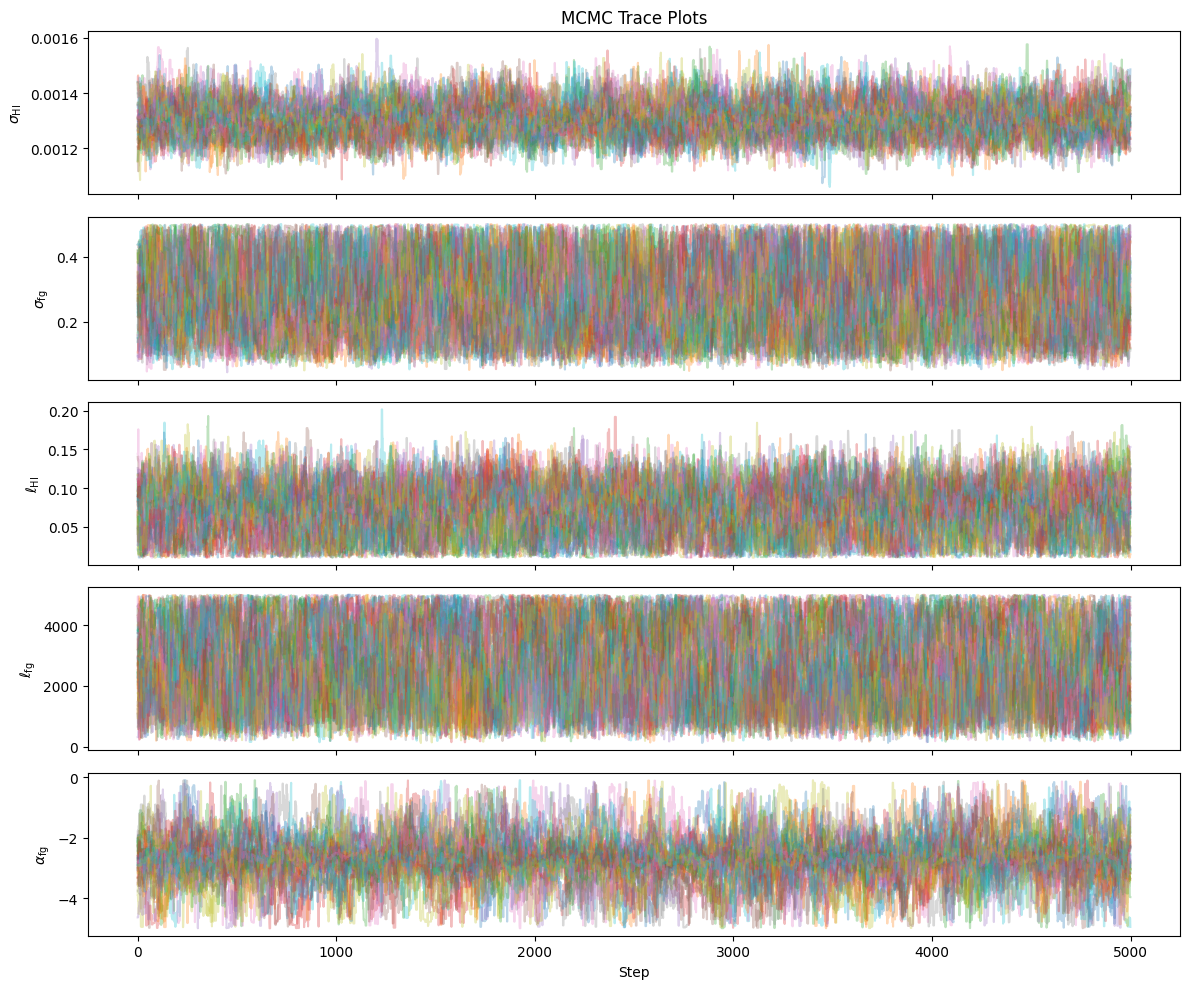

In [194]:
chain = sampler.get_chain()
fig, axes = plt.subplots(ndim, 1, figsize=(12, 10), sharex=True)
for i in range(ndim):
    axes[i].plot(chain[:, :, i], alpha=0.3)
    axes[i].set_ylabel(param_labels[i])
axes[-1].set_xlabel("Step")
axes[0].set_title("MCMC Trace Plots")
plt.tight_layout()
save_project_plot(plt.gcf(), week_number = 8, filename = "mcmc_chain_1.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week8/mcmc_cornerplot_1.pdf


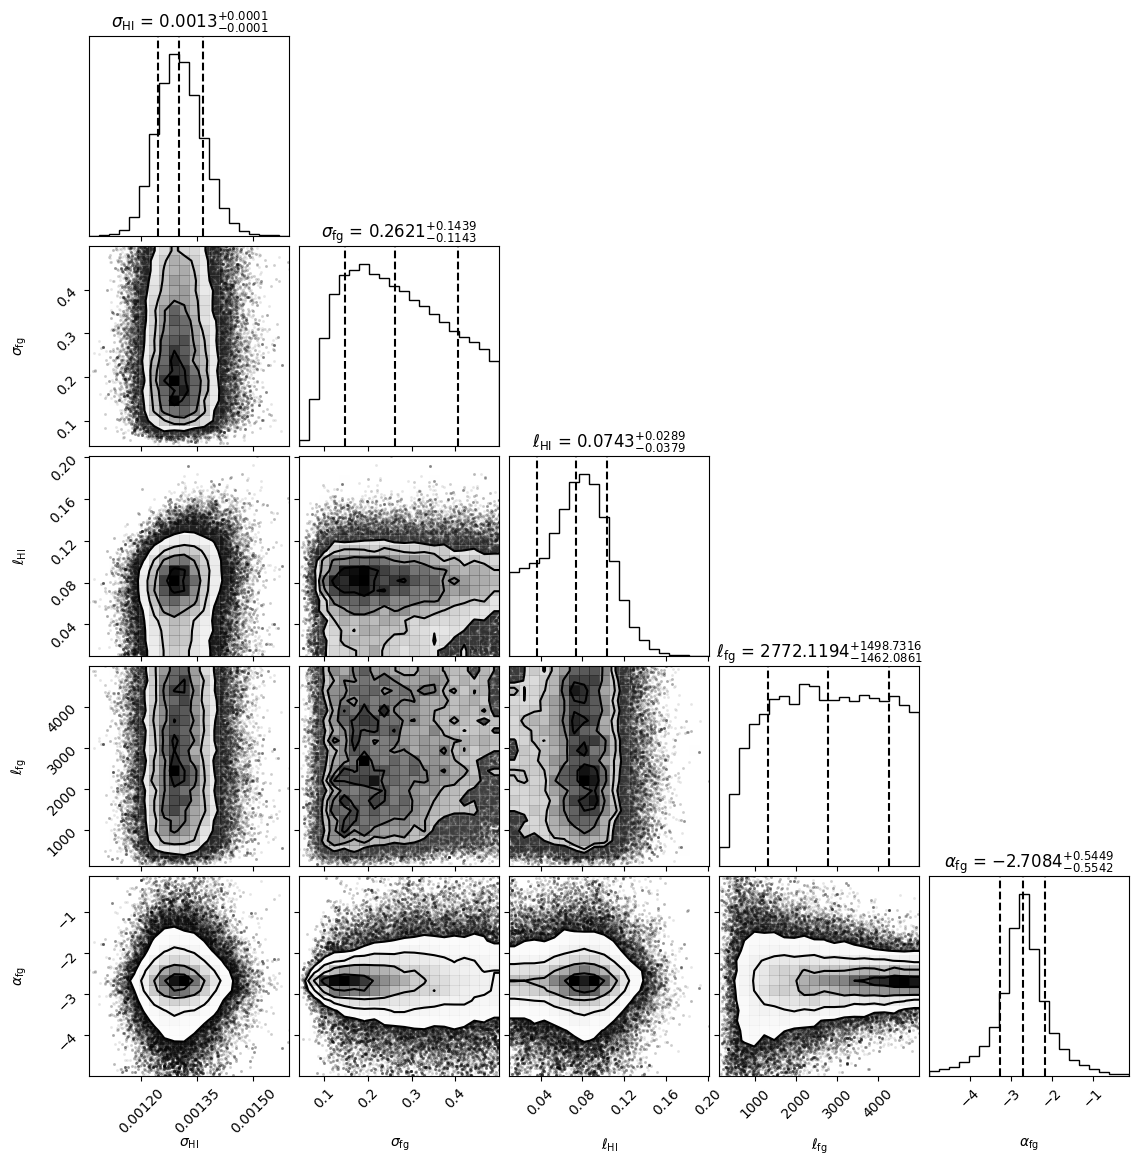

In [195]:
fig = corner.corner(
    samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".4f"
)
save_project_plot(plt.gcf(), week_number = 8, filename = "mcmc_cornerplot_1.pdf")
plt.show()

# Fixed l_fg
## One issue is that l_fg keeps on hitting the upper bounds. So, let's try to fit all the other parameres and set l_fg as the initial guess

In [207]:
## Without sp_indx_fg

In [76]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [77]:
print(l_fg)

400


In [101]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi], dtype = float)
args = (l_fg, mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0)  # hi length scale (MHz)
    #(10.0, 1000.0),  # foreground length scale (MHz)
    #(-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_l_fg_fixed_no_sp_indx_fg, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

In [102]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [0.00129085 0.47553706 0.01      ]
Log-Marginial Likeligood: -1535.7279346702721


In [103]:
print(x0)
print(fitted_pars)

[1.90448375e-04 1.82551820e-01 1.00000000e+00]
[0.00129085 0.47553706 0.01      ]


In [104]:
print(fitted_pars)
fitted_params = [fitted_pars[0], fitted_pars[1], 0.01, 400]
print(fitted_params)

[0.00129085 0.47553706 0.01      ]
[0.0012908486603361372, 0.4755370581120688, 0.01, 400]


In [95]:
#plot_HI_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8, 
#                                         l_fg_fixed = True, sp_indx_fg = False, l_fg = 400)
#foreground_kernal_removal_plots(fitted_pars, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8, sp_indx_fg = True)

In [94]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8, 
#                                                            l_fg_fixed = True, sp_indx_fg = False, l_fg = 400)

In [ ]:
## With sp_indx_fg

In [51]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [52]:
print(l_fg)

400


In [53]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, sp_indx_fg], dtype = float)
args = (l_fg, mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    #(10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_l_fg_fixed, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

In [54]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29120200e-03  1.91443483e-01  1.00000000e-02 -5.00000000e+00]
Log-Marginial Likeligood: -1537.5927825235262


In [55]:
print(x0)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00 -2.70000000e+00]
[ 1.29120200e-03  1.91443483e-01  1.00000000e-02 -5.00000000e+00]


In [58]:
print(fitted_pars)
fitted_params = [fitted_pars[0], fitted_pars[1], fitted_pars[2], 400, fitted_pars[3]]
print(fitted_params)

[ 1.29120200e-03  1.91443483e-01  1.00000000e-02 -5.00000000e+00]
[0.0012912019986229535, 0.19144348275550294, 0.01, 400, -5.0]


In [93]:
#plot_HI_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8, 
#                                         l_fg_fixed = True, sp_indx_fg = True, l_fg = 400)
#foreground_kernal_removal_plots(fitted_pars, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8, sp_indx_fg = True)

In [92]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8, 
#                                                            l_fg_fixed = True, sp_indx_fg = True, l_fg = 400)

In [78]:
tot_map = hi_map + fg_map + noise_map
#tot_map = hi_map + fg_map
cov_tot, __, __, __ = pca_clean(tot_map, 1, weights = mock.w_HI, return_analysis = True, mean_center = True)

In [79]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, sp_indx_fg], dtype = float)
args = (l_fg, mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, 0.5),   # Amplitudes must be positive
    (1e-6, 0.5), 
    (0.01, 2.0),  # hi length scale (MHz)
    #(10.0, 1000.0),  # foreground length scale (MHz)
    (-5, -0.1)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise_l_fg_fixed, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000}) #  method = 'Nelder-Mead'

In [80]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29120200e-03  1.91443483e-01  1.00000000e-02 -5.00000000e+00]
Log-Marginial Likeligood: -1537.5927825235262


In [82]:
print(fitted_pars)
fitted_params = [fitted_pars[0], fitted_pars[1], fitted_pars[2], 400, -2.7]
print(fitted_params)

[ 1.29120200e-03  1.91443483e-01  1.00000000e-02 -5.00000000e+00]
[0.0012912019986229535, 0.19144348275550294, 0.01, 400, -2.7]


In [91]:
#plot_HI_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8)
#plot_foreground_signal_kernal_comparison(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8, 
#                                         l_fg_fixed = True, sp_indx_fg = True, l_fg = 400)
#foreground_kernal_removal_plots(fitted_pars, method = "fixed_l_fg_no_sp_indx", save_plot = True, week_number = 8, sp_indx_fg = True)

In [89]:
#kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_params, method = "fixed_l_fg_sp_indx", save_plot = True, week_number = 8, 
#                                                            l_fg_fixed = True, sp_indx_fg = True, l_fg = 400)